In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "C:/Users/Hi Windows 11 Home/Downloads/clean_log_jul95.parquet"
auto = pd.read_parquet(url)
auto.head(4)

,host,request,status,bytes,timestamp
0,199.72.81.55,GET /history/apollo/ HTTP/1.0,200,6245,1995-07-01 00:00:01-04:00
1,unicomp6.unicomp.net,GET /shuttle/countdown/ HTTP/1.0,200,3985,1995-07-01 00:00:06-04:00
2,199.120.110.21,GET /shuttle/missions/sts-73/mission-sts-73.ht...,200,4085,1995-07-01 00:00:09-04:00
3,burger.letters.com,GET /shuttle/countdown/liftoff.html HTTP/1.0,304,0,1995-07-01 00:00:11-04:00


- `host`: Địa chỉ IP hoặc tên miền của máy khách gửi yêu cầu
- `request`: Chứa phương thức (GET/POST), đường dẫn tài nguyên (URL) và giao thức
- `Timestamp`: Thời điểm yêu cầu được ghi nhận
- `HTTP Reply Code`: Mã phản hồi từ máy chủ
- `bytes`: dung lượng trả về.

In [ ]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2934961 entries, 0 to 2934960
Data columns (total 5 columns):
 #   Column     Dtype                                 
---  ------     -----                                 
 0   host       object                                
 1   request    object                                
 2   status     int64                                 
 3   bytes      int64                                 
 4   timestamp  datetime64[ns, pytz.FixedOffset(-240)]
dtypes: datetime64[ns, pytz.FixedOffset(-240)](1), int64(2), object(2)
memory usage: 112.0+ MB


In [ ]:
auto.status.unique()

array([200, 304, 302, 404, 403, 500, 501, 400])

Status:
- `200`: Success
- `302`: Máy chủ nói rằng tài nguyên bạn tìm đang nằm ở một URL khác tạm thời. Trình duyệt sẽ tự động chuyển bạn sang địa chỉ mới.
- `304`: Máy chủ báo rằng tài nguyên này không có gì thay đổi so với lần cuối bạn truy cập
- `400`: Máy chủ không thể hiểu yêu cầu do cú pháp bị sai.
- `403`: Máy chủ hiểu yêu cầu nhưng từ chối thực hiện. Thường là do bạn không có quyền truy cập
- `404`: Máy chủ không tìm thấy tài nguyên theo URL bạn cung cấp. Có thể địa chỉ đã bị xóa hoặc bạn nhập sai link.
- `500`: Một lỗi chung chung từ phía máy chủ.
- `501`: Máy chủ không hỗ trợ phương thức yêu cầu

### Xác định các method

In [ ]:
auto["method"] = auto["request"].str.extract(r'^([A-Z]+)')
auto.head()

,host,request,status,bytes,timestamp,method
0,199.72.81.55,GET /history/apollo/ HTTP/1.0,200,6245,1995-07-01 00:00:01-04:00,GET
1,unicomp6.unicomp.net,GET /shuttle/countdown/ HTTP/1.0,200,3985,1995-07-01 00:00:06-04:00,GET
2,199.120.110.21,GET /shuttle/missions/sts-73/mission-sts-73.ht...,200,4085,1995-07-01 00:00:09-04:00,GET
3,burger.letters.com,GET /shuttle/countdown/liftoff.html HTTP/1.0,304,0,1995-07-01 00:00:11-04:00,GET
4,199.120.110.21,GET /shuttle/missions/sts-73/sts-73-patch-smal...,200,4179,1995-07-01 00:00:11-04:00,GET


In [ ]:
auto[auto['method'] == np.nan]

,host,request,status,bytes,timestamp,method


In [ ]:
auto.method.unique()

array(['GET', 'HEAD', 'POST', nan], dtype=object)

Method:
- `Head`: Kiểm tra metadata của tài nguyên mà không tải nội dung
- `Get`: Gửi dữ liệu lên serve
- `Post`: Gửi dữ liệu lên serve để xử lý

### Xử lý Gap - Khoảng trống tạo ra do không có thêm request

In [ ]:
# 1. TẠO DF_1M
df_1m = auto.set_index('timestamp').resample('1min').agg({
    'status': 'count',
    'bytes': 'sum'
}).rename(columns={'status': 'rps', 'bytes': 'throughput'})

# 2. TẠO KHUNG THỜI GIAN LIÊN TỤC
full_range = pd.date_range(start=df_1m.index.min(), end=df_1m.index.max(), freq='1min')
df_final = df_1m.reindex(full_range).reset_index().rename(columns={'index': 'timestamp'})

# 3. XỬ LÝ MÚI GIỜ (Đảm bảo khớp với dữ liệu gốc)
storm_start = pd.to_datetime('1995-08-01 14:52:00-0400')
storm_end = pd.to_datetime('1995-08-03 04:36:00-0400')

if df_final['timestamp'].dt.tz is None:
    df_final['timestamp'] = df_final['timestamp'].dt.tz_localize('-0400')

# 4. GẮN NHÃN REGIME
recovery_limit = storm_end + pd.Timedelta(minutes=30)

conditions = [
    (df_final['timestamp'] < storm_start),                                      # Pre-storm
    (df_final['timestamp'] >= storm_start) & (df_final['timestamp'] <= storm_end), # Outage
    (df_final['timestamp'] > storm_end) & (df_final['timestamp'] <= recovery_limit),# Recovery
    (df_final['timestamp'] > recovery_limit)                                    # Post-storm
]

choices = ['Regime-Pre-Storm', 'Outage_Storm', 'Recovery_Period', 'Regime-Post-Storm']

df_final['regime'] = np.select(conditions, choices, default='Unknown')

# 5. XỬ LÝ DỮ LIỆU THIẾU (IMPUTATION)
df_final['is_imputed'] = df_final['rps'].isna().astype(int)
df_final['rps'] = df_final['rps'].fillna(0)
df_final['throughput'] = df_final['throughput'].fillna(0)

# Kiểm tra kết quả
print("Thống kê các vùng dữ liệu (Sau khi tối ưu):")
print(df_final['regime'].value_counts())

Thống kê các vùng dữ liệu (Sau khi tối ưu):
regime
Regime-Pre-Storm     45532
Regime-Post-Storm    28493
Outage_Storm          2265
Recovery_Period         30
Name: count, dtype: int64


In [ ]:
df_final

,timestamp,rps,throughput,regime,is_imputed
0,1995-07-01 00:00:00-04:00,42,608453,Regime-Pre-Storm,0
1,1995-07-01 00:01:00-04:00,61,910128,Regime-Pre-Storm,0
2,1995-07-01 00:02:00-04:00,57,628556,Regime-Pre-Storm,0
3,1995-07-01 00:03:00-04:00,71,1747389,Regime-Pre-Storm,0
4,1995-07-01 00:04:00-04:00,70,1383149,Regime-Pre-Storm,0
...,...,...,...,...,...
76315,1995-08-22 23:55:00-04:00,13,319726,Regime-Post-Storm,0
76316,1995-08-22 23:56:00-04:00,21,436101,Regime-Post-Storm,0
76317,1995-08-22 23:57:00-04:00,29,334910,Regime-Post-Storm,0
76318,1995-08-22 23:58:00-04:00,29,283098,Regime-Post-Storm,0


In [ ]:
df_final.is_imputed.sum()

np.int64(0)

Trong `df_final`, `is_imputed` không có giá trị nào trả về 1. Như vậy dữ liệu đang làm việc là chuỗi trạng thái hợp lệ

### Kiểm tra Thời gian giữa các lần request


In [ ]:
# Tạo bản sao df_clone cho dataset gốc
df_clone = auto

# Tách thành 2 dataset
df_before_storm = df_clone[df_clone.timestamp < storm_start]
df_after_storm = df_clone[df_clone.timestamp > storm_end]

# tạo iat cho từng 2 dataset
df_before_storm['iat'] = df_before_storm['timestamp'].diff().dt.total_seconds()
df_after_storm['iat'] = df_after_storm['timestamp'].diff().dt.total_seconds()

# lọc bỏ nan ở các dòng đầu tiên của dữ liệu:
df_before_storm = df_before_storm.dropna()
df_after_storm = df_after_storm.dropna()

C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_18248\2062417887.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_before_storm['iat'] = df_before_storm['timestamp'].diff().dt.total_seconds()
C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_18248\2062417887.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_storm['iat'] = df_after_storm['timestamp'].diff().dt.total_seconds()


In [ ]:
df_before_storm

,host,request,status,bytes,timestamp,method,iat
1,unicomp6.unicomp.net,GET /shuttle/countdown/ HTTP/1.0,200,3985,1995-07-01 00:00:06-04:00,GET,5.0
2,199.120.110.21,GET /shuttle/missions/sts-73/mission-sts-73.ht...,200,4085,1995-07-01 00:00:09-04:00,GET,3.0
3,burger.letters.com,GET /shuttle/countdown/liftoff.html HTTP/1.0,304,0,1995-07-01 00:00:11-04:00,GET,2.0
4,199.120.110.21,GET /shuttle/missions/sts-73/sts-73-patch-smal...,200,4179,1995-07-01 00:00:11-04:00,GET,0.0
5,burger.letters.com,GET /images/NASA-logosmall.gif HTTP/1.0,304,0,1995-07-01 00:00:12-04:00,GET,1.0
...,...,...,...,...,...,...,...
1925704,140.142.77.1,GET /shuttle/missions/sts-69/images/KSC-95EC-1...,200,761,1995-08-01 14:42:45-04:00,GET,2.0
1925705,192.251.220.242,GET /history/apollo/apollo.html HTTP/1.0,200,3260,1995-08-01 14:43:10-04:00,GET,25.0
1925706,146.154.25.183,GET /shuttle/missions/sts-69/mission-sts-69.ht...,200,10566,1995-08-01 14:43:18-04:00,GET,8.0
1925707,128.183.76.159,GET /ksc.html HTTP/1.0,200,7280,1995-08-01 14:43:27-04:00,GET,9.0


In [ ]:
plt.figure(figsize=(10,6))

# Vẽ phân phối trước bão và sau bão
iat_before = df_before_storm['iat']
iat_after = df_after_storm['iat']

<Figure size 1000x600 with 0 Axes>

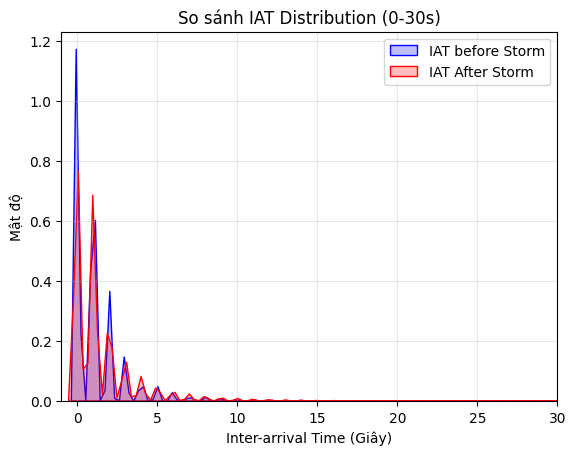

In [ ]:
sns.kdeplot(iat_before[iat_before < 60], label='IAT before Storm', color='blue', fill=True)
sns.kdeplot(iat_after[iat_after < 60], label='IAT After Storm', color='red', fill=True)

# Quan trọng: Giới hạn trục X để phóng to
plt.xlim(-1, 30)

plt.title('So sánh IAT Distribution (0-30s)')
plt.xlabel('Inter-arrival Time (Giây)')
plt.ylabel('Mật độ')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Kiểm định: Giá trị IAT chủ yếu nằm trong khoản [0-5] và phân phối của cả 2 giai đoạn trước và sau bão đều là phân phối skewed/heavy-tail

In [ ]:
# trước khi hệ thống đóng vì bão
mask_before = (df_before_storm['iat'] >= 0) & (df_before_storm['iat'] <= 5)
number_iat_before = df_before_storm[mask_before]['iat'].count()
print("Tỷ lệ số iat nằm trong khoảng 0 đến 5:")
print(number_iat_before * 1.0 / df_before_storm.shape[0] * 100.0)

Tỷ lệ số iat nằm trong khoảng 0 đến 5:
96.44597323678677


In [ ]:
# sau khi hệ thống mở lại sau bão:
mask_after = (df_after_storm['iat'] >= 0) & (df_after_storm['iat'] <= 5)
number_iat_after = df_after_storm[mask_after]['iat'].count()
print("Tỷ lệ số iat nằm trong khoảng 0 đến 5:")
print(number_iat_after * 1.0 / df_after_storm.shape[0] * 100.0)

Tỷ lệ số iat nằm trong khoảng 0 đến 5:
93.80962997091885


Ở cả 2 regime, giá trị IAT tập trung hầu hết tại khoảng [0,5]. Dựa vào quan sát phân phối trong khoảng Inter-arrival Time được xét cùng đuôi có xu hướng kéo dài, hành vi của iat cho ta phân phối có đuôi nặng kéo dài
$\to$ Giá trị **`mean`** không đại diện đúng cho dữ liệu

$\to$ **Insight**: Các metric dựa vào **`mean`** không phù hợp cho bài toán này

#### Kiểm định hiện tượng Burst và hình thành cụm

**Burst** là hiện tượng event dồn cụm trong thời gian ngắn, được thể hiện ở việc có các cluster ngắn cường độ cao cùng các gap dài cường độ thấp, gắn với động lực học của cơ chế sinh dữ liệu thời gian

Nhằm kiểm định tính **Burst**, ta sử dụng hệ số CV score (Coefficient of Variation):
$$
    CV_{score} = \frac{\sigma_{iat}}{\mu_{iat}}
$$

In [ ]:
def calculate_multi_window_cv(df_raw, windows=[1, 3, 5, 10]):
    results = {}

    for w in windows:
        # Tính CV cho từng cửa sổ w phút
        # Lưu ý: Cửa sổ càng lớn, CV thường có xu hướng giảm nếu dữ liệu mượt
        # Nhưng với dữ liệu Burst, CV vẫn sẽ giữ ở mức cao
        group = df_raw.groupby(pd.Grouper(key='timestamp', freq=f'{w}min'))['iat']
        stats = group.agg(['std', 'mean'])
        cv_name = f'cv_{w}min'
        results[cv_name] = stats['std'] / (stats['mean'] + 1e-9)

    return pd.DataFrame(results)

# Chạy thử để so sánh
df_multi_cv = calculate_multi_window_cv(df_before_storm)
print(df_multi_cv.describe())

            cv_1min       cv_3min      cv_5min     cv_10min
count  40278.000000  13496.000000  8105.000000  4056.000000
mean       1.231745      1.314674     1.349228     1.399734
std        0.305037      0.342801     0.414406     0.578913
min        0.000000      0.261891     0.162761     0.860910
25%        1.053819      1.160870     1.195357     1.230392
50%        1.202373      1.267795     1.288714     1.312623
75%        1.362565      1.388157     1.400491     1.416738
max       10.035456     11.306952    15.098067    19.428812


In [ ]:
df_multi_cv_1 = calculate_multi_window_cv(df_after_storm)
print(df_multi_cv_1.describe())

            cv_1min      cv_3min      cv_5min     cv_10min
count  27933.000000  9384.000000  5648.000000  2841.000000
mean       1.242165     1.343695     1.384377     1.437162
std        0.310039     0.339609     0.397192     0.503134
min        0.000000     0.397748     0.331291     0.687058
25%        1.055191     1.185750     1.233572     1.282700
50%        1.214935     1.306400     1.338175     1.371978
75%        1.394258     1.441067     1.457238     1.475724
max        9.701814    10.829165    10.829165    12.356525


Cả 2 tập dataset đều cho các rolling cv_score > 1, ám chỉ tốc độ thay đổi var nhanh hơn trung bình mean của iat. Điều này chứng tỏ rằng dữ liệu thời gian của tính burst và hình thành cụm ngắn với cường độ cao

Ngoài ra: ở cả 2 regime, CV score đều tăng củng cố về hiện tượng **burst** của dữ liệu.

Đặc biệt hơn: Ở các window unit tương ứng, tỉ số $CV_{trước bão}/CV_{sau bão} \approx 1$, ám chỉ cơn bão không làm thay đổi cấu trúc nội tại của burst

**Insight:** Variance mang tín hiệu, không phải noise. Nó là tín hiệu cảnh báo sớm của burst, ám chỉ rằng hệ thống cần được scale trước khi gặp spike cũng như tải trọng không tăng tuyến tính

### Dữ liệu có độc lập hay không?

Từ các insight đã suy luận từ trước, khẳng định dữ liệu đã cho là không độc lập

## Lựa chọn Cửa sổ thời gian cho Decision Layer và Model Layer

- Dựa vào các insight đã chứng minh ở trước, các thông tin quan trọng tập trung ở high-frequency. 1m là mức lý tưởng để giữ lại cấu trúc burst structure, tránh noise so với giây
- Với Decision: 5m tránh Burst dồn dập, hệ thống có đủ thời gian để phản ứng, tạo hysteresis tự nhiên

### Tương quan CV score, Throughput và RPS

#### CV và RPS

In [ ]:
def prepare_eda_dashboard_data(df_raw, freq):
    group = df_raw.groupby(pd.Grouper(key='timestamp', freq=freq))

    df = group.agg(
        rps=('iat', 'count'),
        throughput=('bytes', 'sum'),
        iat_mu=('iat', 'mean'),
        iat_sigma=('iat', 'std')
    ).reset_index()

    # Tính CV - Thước đo Chaos
    df['cv'] = df['iat_sigma'] / (df['iat_mu'] + 1e-9)
    return df

df_1m_bs = prepare_eda_dashboard_data(df_before_storm, '1min')
df_1m_as = prepare_eda_dashboard_data(df_after_storm, '1min')

df_5m_bs = prepare_eda_dashboard_data(df_before_storm, '5min')
df_5m_as = prepare_eda_dashboard_data(df_after_storm, '5min')

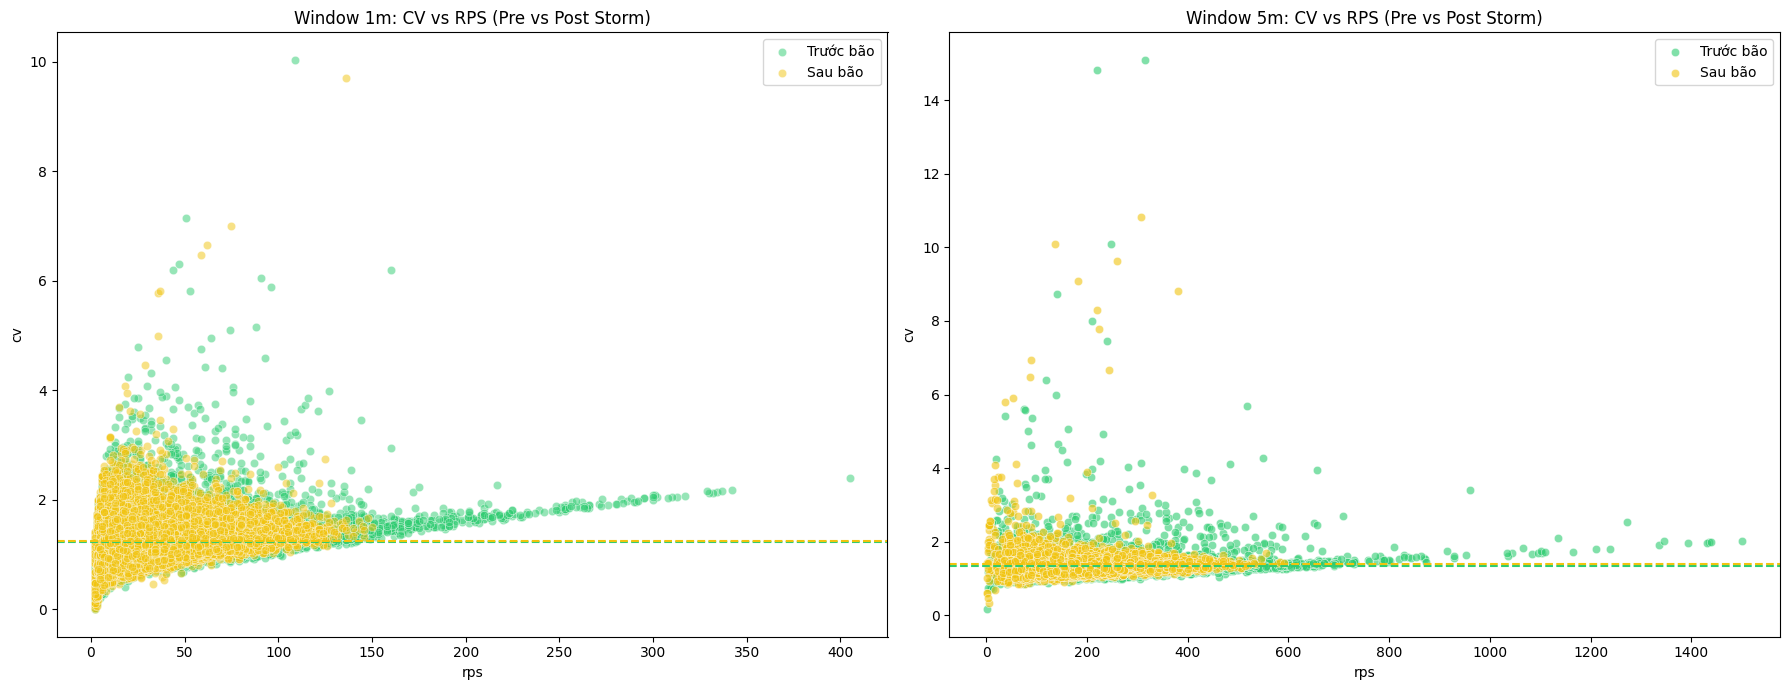

In [ ]:
def plot_pre_post_storm(df_pre_1m, df_post_1m, df_pre_5m, df_post_5m):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Màu sắc đại diện cho trạng thái
    color_pre = '#2ecc71'  # Xanh lá: Trước bão
    color_post = '#f1c40f' # Vàng: Sau bão (hồi phục)

    # --- BIỂU ĐỒ 1: THANG 1 PHÚT ---
    sns.scatterplot(data=df_pre_1m, x='rps', y='cv', color=color_pre, alpha=0.5, label='Trước bão', ax=axes[0])
    sns.scatterplot(data=df_post_1m, x='rps', y='cv', color=color_post, alpha=0.5, label='Sau bão', ax=axes[0])

    axes[0].set_title('Window 1m: CV vs RPS (Pre vs Post Storm)')
    axes[0].axhline(df_pre_1m.cv.mean(), color=color_pre, linestyle='--')
    axes[0].axhline(df_post_1m.cv.mean(), color=color_post, linestyle='--')

    # --- BIỂU ĐỒ 2: THANG 5 PHÚT ---
    sns.scatterplot(data=df_pre_5m, x='rps', y='cv', color=color_pre, alpha=0.6, label='Trước bão', ax=axes[1])
    sns.scatterplot(data=df_post_5m, x='rps', y='cv', color=color_post, alpha=0.6, label='Sau bão', ax=axes[1])

    axes[1].set_title('Window 5m: CV vs RPS (Pre vs Post Storm)')
    axes[1].axhline(df_pre_5m.cv.mean(), color=color_pre, linestyle='--')
    axes[1].axhline(df_post_5m.cv.mean(), color=color_post, linestyle='--')

    plt.tight_layout()
    plt.show()

plot_pre_post_storm(df_1m_bs, df_1m_as, df_5m_bs, df_5m_as)

- Khi RPS thấp: CV có xu hướng phân tán mạnh và rất cao, ám chỉ request đến không đều mà tập trung dày tại một thời điểm, có các khoảng lặng xen kẽ
- Khi RPS cao: Cv có xu hướng co lại sát 1-2
- Không xuất hiện xu hướng tăng CV do tăng RPS
- Giai đoạn trước bão và sau bão đều cho nón ngược và cả biên CV, có thể bão chỉ gây gián đoạn hạ tầng chứ không hề làm thay đổi cơ chế sinh nhu cầu.
- Ở window 5m: CV trung bình thấp hơn

$\to$ **Kết luận định tính:** Bất thường thời gian tập trung ở vùng tải thấp-trung bình nhưng có nhịp request bất ổn, không phải do đông người truy cập.

#### CV và Throughput

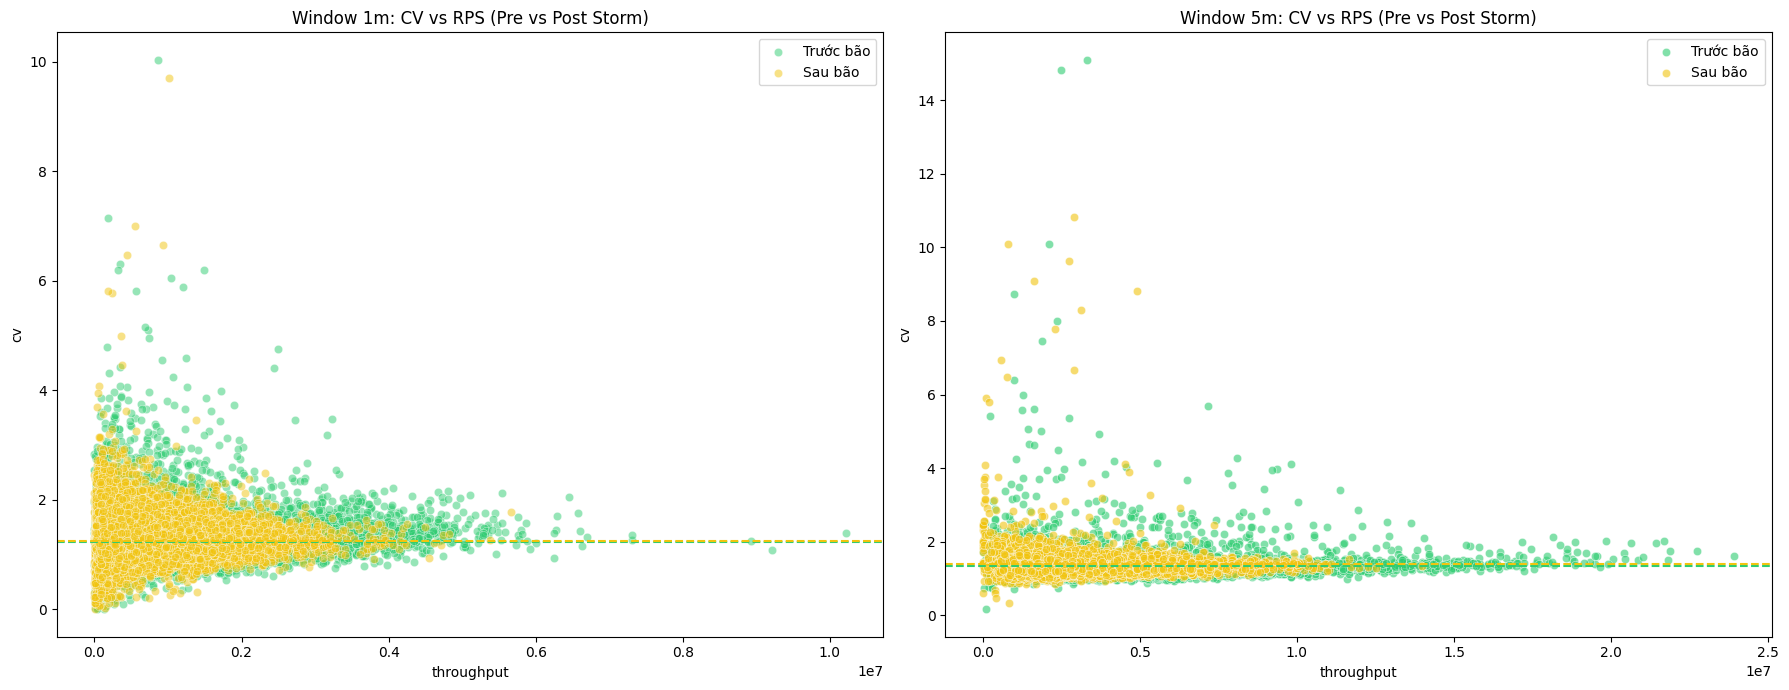

In [ ]:
def plot_pre_post_storm_bytes(df_pre_1m, df_post_1m, df_pre_5m, df_post_5m):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Màu sắc đại diện cho trạng thái
    color_pre = '#2ecc71'  # Xanh lá: Trước bão
    color_post = '#f1c40f' # Vàng: Sau bão (hồi phục)

    # --- BIỂU ĐỒ 1: THANG 1 PHÚT ---
    sns.scatterplot(data=df_pre_1m, x='throughput', y='cv', color=color_pre, alpha=0.5, label='Trước bão', ax=axes[0])
    sns.scatterplot(data=df_post_1m, x='throughput', y='cv', color=color_post, alpha=0.5, label='Sau bão', ax=axes[0])

    axes[0].set_title('Window 1m: CV vs RPS (Pre vs Post Storm)')
    axes[0].axhline(df_pre_1m.cv.mean(), color=color_pre, linestyle='--')
    axes[0].axhline(df_post_1m.cv.mean(), color=color_post, linestyle='--')

    # --- BIỂU ĐỒ 2: THANG 5 PHÚT ---
    sns.scatterplot(data=df_pre_5m, x='throughput', y='cv', color=color_pre, alpha=0.6, label='Trước bão', ax=axes[1])
    sns.scatterplot(data=df_post_5m, x='throughput', y='cv', color=color_post, alpha=0.6, label='Sau bão', ax=axes[1])

    axes[1].set_title('Window 5m: CV vs RPS (Pre vs Post Storm)')
    axes[1].axhline(df_pre_5m.cv.mean(), color=color_pre, linestyle='--')
    axes[1].axhline(df_post_5m.cv.mean(), color=color_post, linestyle='--')

    plt.tight_layout()
    plt.show()

plot_pre_post_storm_bytes(df_1m_bs, df_1m_as, df_5m_bs, df_5m_as)

- Khi Throughput thấp: CV rất cao và phân tán: nghĩa là ít byte không đồng nghĩa với ổn định
- Khi throughput tăng: CV giảm và co lại
- CV-Throughput cho thấy burst không phụ thuộc payload, thực tế là đặc tính nội sinh của hành vi truy cập, không phải do cường độ tài nguyên

### Phân phối của RPS và Throughput

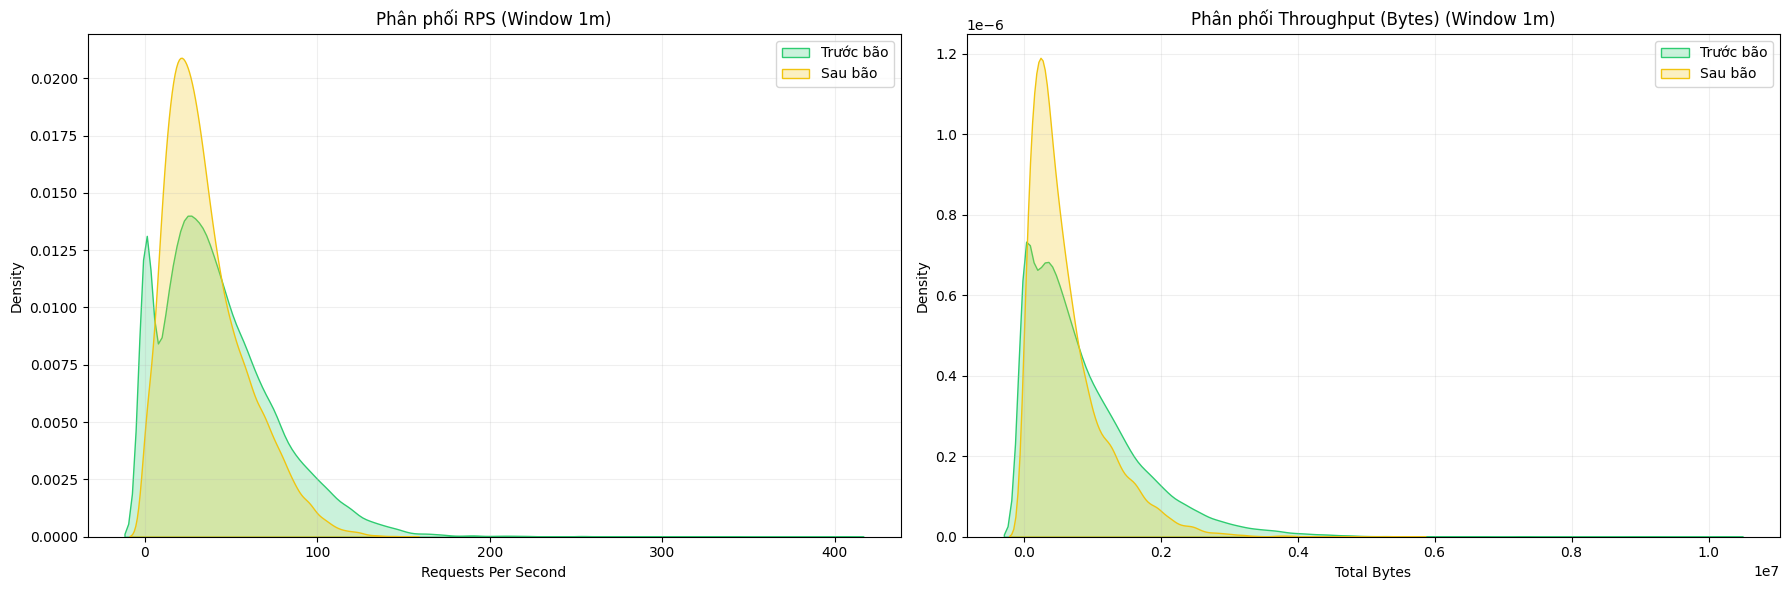

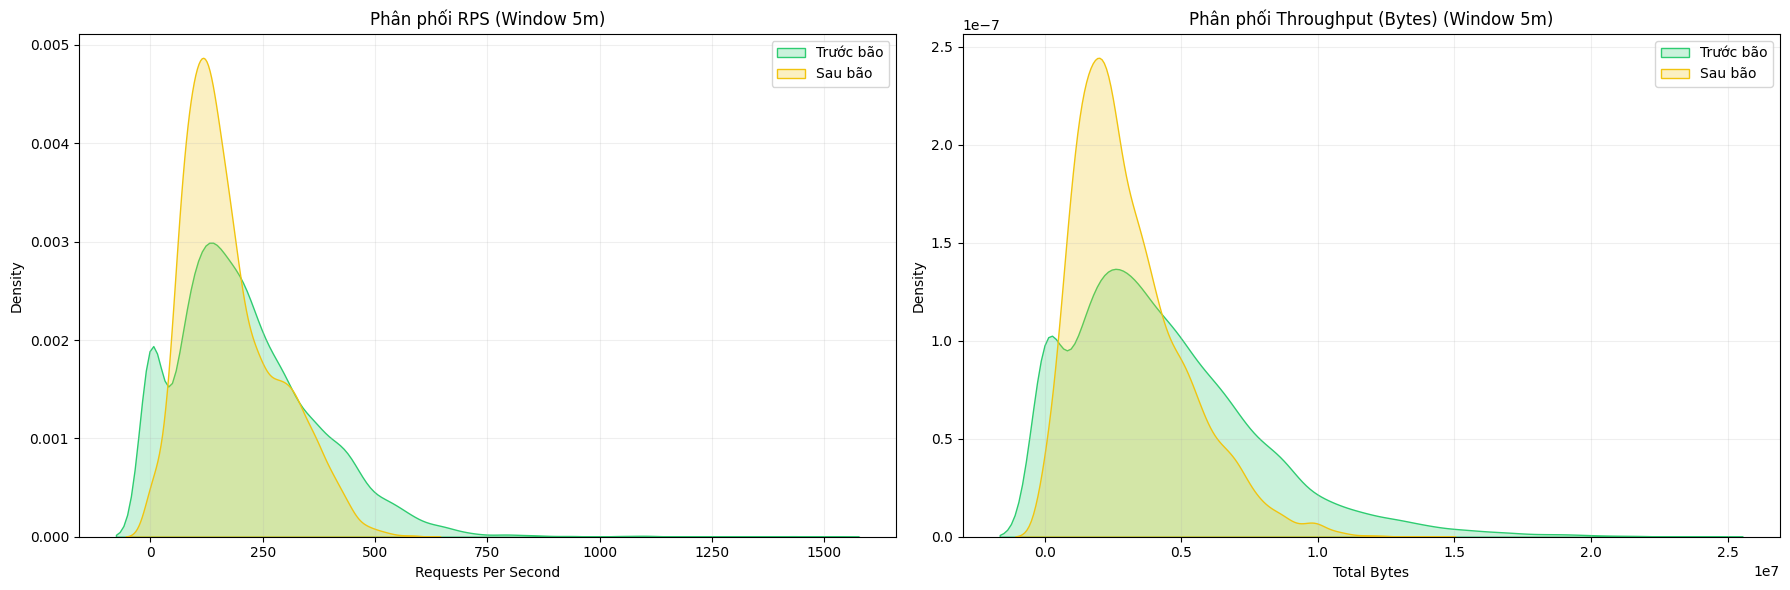

In [ ]:
def plot_distributions(df_pre, df_post, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Phân phối RPS (Intensity)
    sns.kdeplot(df_pre['rps'], fill=True, color='#2ecc71', label='Trước bão', ax=axes[0])
    sns.kdeplot(df_post['rps'], fill=True, color='#f1c40f', label='Sau bão', ax=axes[0])
    axes[0].set_title(f'Phân phối RPS {title_suffix}')
    axes[0].set_xlabel('Requests Per Second')

    # 2. Phân phối Throughput (Bytes)
    sns.kdeplot(df_pre['throughput'], fill=True, color='#2ecc71', label='Trước bão', ax=axes[1])
    sns.kdeplot(df_post['throughput'], fill=True, color='#f1c40f', label='Sau bão', ax=axes[1])
    axes[1].set_title(f'Phân phối Throughput (Bytes) {title_suffix}')
    axes[1].set_xlabel('Total Bytes')

    for ax in axes:
        ax.legend()
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# Vẽ cho cả 2 cấp độ window
plot_distributions(df_1m_bs, df_1m_as, "(Window 1m)")
plot_distributions(df_5m_bs, df_5m_as, "(Window 5m)")

Sau bão, hệ thống trở về một điểm cân bằng mới với tải trung bình cao hơn, nhưng nhịp sinh request vẫn hỗn loạn như cũ — burst không đến từ bão, bão chỉ làm lộ rõ nó.

### Autocorrelation Function nhằm xác định Memory Feature và Lag Feature

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

def create_specific_lags(df, columns, lags=[1, 3, 5, 10, 15, 60]):
    """
    Tạo Lag features chỉ cho các mốc cụ thể.
    """
    df_lagged = df.copy()
    for col in columns:
        for lag in lags:
            df_lagged[f'{col}_lag_{lag}'] = df_lagged[col].shift(lag)

    return df_lagged

# Danh sách cột mục tiêu
target_cols = ['rps', 'throughput', 'cv']
specific_lags = [1, 3, 5, 10, 15, 60]

# Áp dụng cho 2 tập dữ liệu
df_pre_lagged_1m = create_specific_lags(df_1m_bs, target_cols, specific_lags)
df_pre_lagged_5m = create_specific_lags(df_5m_bs, target_cols, specific_lags)
df_post_lagged_1m = create_specific_lags(df_1m_as, target_cols, specific_lags)
df_post_lagged_5m = create_specific_lags(df_5m_as, target_cols, specific_lags)

--- PHÂN TÍCH ACF TRƯỚC BÃO (1m) ---


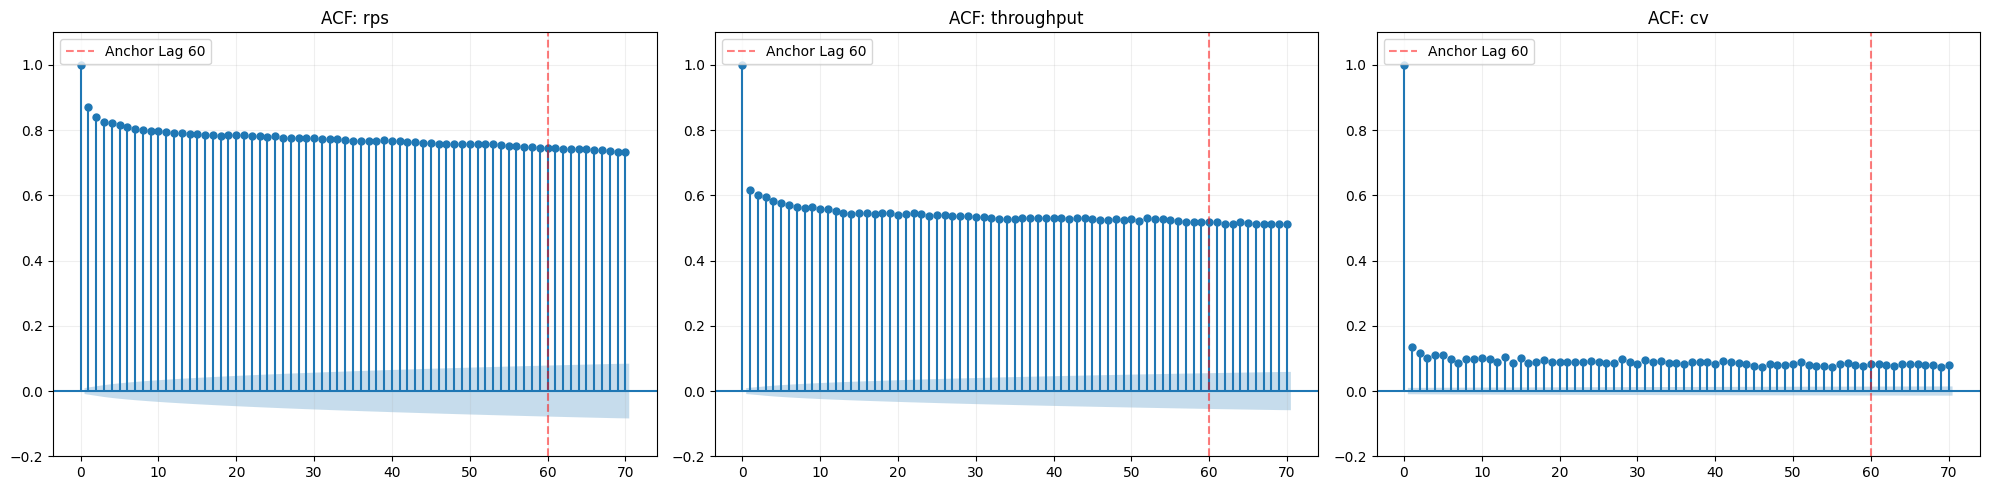

--- PHÂN TÍCH ACF SAU BÃO (1m) ---


In [ ]:
def plot_acf_with_anchor(df, columns, max_lag=70, anchor=60):
    n_cols = len(columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(20, 5))

    for i, col in enumerate(columns):
        plot_acf(df[col].dropna(), lags=max_lag, ax=axes[i], title=f'ACF: {col}')
        # Vẽ đường thẳng đỏ tại mốc 60 để soi độ tương quan
        axes[i].axvline(anchor, color='red', linestyle='--', alpha=0.5, label=f'Anchor Lag {anchor}')
        axes[i].set_ylim(-0.2, 1.1)
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

print("--- PHÂN TÍCH ACF TRƯỚC BÃO (1m) ---")
plot_acf_with_anchor(df_pre_lagged_1m, target_cols)

print("--- PHÂN TÍCH ACF SAU BÃO (1m) ---")
plot_acf_with_anchor(df_post_lagged_1m, target_cols)

In [ ]:
print("--- PHÂN TÍCH ACF TRƯỚC BÃO (5m) ---")
plot_acf_with_anchor(df_pre_lagged_5m, target_cols)

print("--- PHÂN TÍCH ACF SAU BÃO (5m) ---")
plot_acf_with_anchor(df_post_lagged_5m, target_cols)

Biểu đồ ACF cho thấy:
- Dữ liệu có phụ thuộc thời gian ngắn (ACF của RPS/Throuput tương đối cao, hành động bị chi phối bởi trend)
- Đặc biệt của CV: ACF rất thấp và giảm về 0 khi lag tăng dần $\to$ Lag có ý nghĩa decision hơn dự đoán

### Error Rate và RPS

In [ ]:
def prepare_error_data(df):
    error_df = df.groupby(pd.Grouper(key = 'timestamp', freq = '1min')).agg(
        total_requests = ('request', 'count'),
        total_errors = ('status', lambda x: (x >= 400).sum())
    ).reset_index()

    error_df['error_rate'] = (error_df['total_errors'] / error_df['total_requests']) * 100

    return error_df.fillna(0)

# Dữ liệu trước bão
error_bs = prepare_error_data(df_before_storm)
# Dữ liệu sau bão
error_as = prepare_error_data(df_after_storm)

In [ ]:
def plot_rps_vs_error(df):
    plt.figure(figsize=(12, 7))
    # Sử dụng màu sắc để thể hiện độ hỗn loạn (CV)
    scatter = plt.scatter(df['total_requests'], df['error_rate'], cmap='viridis', alpha=0.6)

    plt.xlabel('Requests Per Second (RPS)')
    plt.ylabel('Error Rate (%)')
    plt.title('Hồi quy RPS vs Error Rate: Xác định ngưỡng sập hệ thống')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_rps_vs_error(error_bs)

In [ ]:
plot_rps_vs_error(error_as)

- Ở cả hai biểu đồ đều xuất hiện phân bố hình quạt cong: RPS thấp có thể dẫn đến error rất cao. Khi RPS tăng error rate giảm nhanh về 0.
- Các dải song song cho thấy error rate bị chi phối bởi trạng thái của hệ thống, không phải nhiễu ngẫu nhiên
- Không tồn tại quan hệ tuyến tính dương, ngược lại error cao chủ yếu xảy ra khi hệ thống có tải thấp nhưng không ổn định
+ Biểu đồ trước bão: RPS trả rộng tới gần 400 request. Khi RPS từ khoảng 150-200, error sát 0 ổn định. Các error rate cao chỉ tập trung ở vùng RPS thấp
+ Biểu đồ sau bão: RPS thấp hơn, ở cùng mức 20-80: error rate cao hơn và phân tán mạnh hơn so với bão.

**Trọng tâm:** Error rate phản ánh trạng thái của hệ thống. Quyết định Scaling cần kết hợp với error rate để phát hiện sắp sập hệ thống